In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import BlackBody
from astropy import units as u
from astropy import constants as const
from scipy.special import wofz
import pandas as pd
from hapi import *

HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

## FUNCTIONS

In [2]:
def surface_gravity(M_p, R_p):
    """
    Determines surface gravity of the planet (in ms-2)

    :param M_p: mass of the planet (in kg) 
    :type M_p: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :return: g
    :rtype: float
    
    """

    g = const.G.value * M_p / R_p**2

    return g

def scale_height(T_atm, Mm, M_p, R_p):
    """
    Determines the scale height of the atmosphere (in m) 

    :param T_atm: temperature of the atmosphere (in K) 
    :type T_atm: float

    :param Mm: molecular mass (g/mol)
    :type Mm: float

    :param M_p: mass of the planet (in kg) 
    :type M_p: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :return: H
    :rtype: float
    """
    g = surface_gravity(M_p, R_p)
    H = (const.k_B.value * T_atm) / ((Mm/(1000 * const.N_A.value)) * g)

    return H

def surface_number_density(P0, T_atm):
    """
    Determines surface number density with ideal gas law (in m-3)

    :param P0: pressure of the atmosphere (in Pa) 
    :type P0: float

    :param T_atm: temperature of the atmosphere (in K) 
    :type T_atm: float

    :return: n0
    :rtype: float
    """
    n0 = (P0 / (const.k_B.value * T_atm))

    return n0

def absorption_cross_section(centre, width, sigma0, wavelength):
    """
    Determines absorption cross section assuming a gaussian centered at a particular wavelength (in m2) 

    :param centre: central wavelength (in microns) 
    :type centre: float

    :param width: width of the gaussian (dimensionless)
    :type width: float

    :param sigma0: value for the central absorption cross section (in m2)
    :type sigma0: float

    :param wavelength: wavelength (in microns)
    :type width: float
    
    :return: sigma_lambda
    :rtype: float
    """
    sigma_lambda = sigma0 * np.exp(- ((wavelength - centre) / width)**2)

    return sigma_lambda

def altitude_tau_1(sigma_lambda, n0, R_p, H):
    """
    Determines the altitude z where tau is 1 (in m)

    :param sigma_lambda: absorption cross section (m2)
    :type centre: float

    :param n0: surface number density with ideal gas law (in m-3)
    :type width: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :param H: scale height of the atmosphere (in m) 
    :type width: float
    
    :return: z_tau1
    :rtype: float
    """
    
    inside_log = (sigma_lambda * n0 * np.sqrt(2 * np.pi * R_p * H))
    #Important note, if the value inside_log is smaller than one, then the value of altitude_tau_1 would be negative
    #We could study that case separatly and just say that in that case the atmosphere is optically thin and make z=0 for example
    #I am not including that case in this first version. 
    z_tau1 = H * np.log(inside_log)

    return z_tau1

def eff_radius_planet(R_p, z_tau1):
    """
    Determines the effective radius of the planet with atmosphere (in m) 

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :param z_tau1: the altitude z where tau is 1 (in m) 
    :type z_tau1: float

    :return: R_eff
    :rtype: float
    
    """
    
    R_eff = R_p + z_tau1

    return R_eff
    
def transit_depth_lambda(R_eff, R_star):
    """
    Determines the wavelength-dependent depth of an exoplanet transit.

    :param R_eff: the effective radius of the planet with atmosphere (in m)
    :type Rp: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :return: delta_lambda
    :rtype: float
    """

    delta_lambda = (R_eff / R_star)**2
    return delta_lambda

def density_profile_atm_linearT(z, T_atm_0, Mm, M_p, R_p, P0, constant):
    """
    Determines the density profile (in m-3) of a certain species in the atmosphere based on simple hydrostatic equilibrium + ideal gas law.
    This function assumes a temperature T(z) = T_atm_0 - constant * z. 

    :param T_atm_0: temperature of the atmosphere at the surface (in K) 
    :type T_atm_0: float

    :param Mm: molecular mass (g/mol)
    :type Mm: float

    :param M_p: mass of the planet (in kg) 
    :type M_p: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :param P0: pressure of the atmosphere (in Pa) 
    :type P0: float

    :param constant: constant in the linear expression (in K/m)
    :type constnat: float

    :return: n
    :rtype: float
    
    """

    T = T_atm_0 - constant * z 
    g = surface_gravity(M_p, R_p)
    n0 = surface_number_density(P0, T_atm_0)

    n = (P0 / (const.k_B.value * T)) * (1 - constant * z / T_atm_0) ** ((g * (Mm/(1000 * const.N_A.value))) / (constant * const.k_B.value))

    return n

def gaussian_profile(sigma,center,frequency):
    return((1/(sigma*np.sqrt(2*np.pi)))* np.exp(-0.5*((frequency-center) / sigma)**2))

def lorentz_profile(delta, center, frequency):
    return delta / (np.pi * ((frequency-center)**2 + delta**2))

def voigt_profile(sigma,delta,center,frequency):
    return((np.real(wofz(((frequency-center) + 1j * delta) / (sigma * np.sqrt(2)))))/ (sigma * np.sqrt(2 * np.pi)))

def temperature(z, T_atm_0, constant):
    return T_atm_0 - constant * z

def partition_function(energy_levels, degeneracies, T_atm):
    """
    Determines the value of the partition function of Boltzmann distribution 
    (assuming constant temperature in the atmosphere)
    
    :param energy_levels: retrieved energy levels for the species (in J) 
    :type energy_levels: array

    :param degeneracies: degeneracies of the retrieved levels (dimensionless) 
    :type degeneracies: array

    :param T_atm: temperature of the atmosphere assumed constant (in K) 
    :type T_atm: float
    



    :return: Z
    :rtype: float
    """
    
    M = len(energy_levels)
    Z = 0
    
    for i in range(M):
        Z += degeneracies[i] * np.exp(-energy_levels[i]/(const.k_B.value * T_atm))
    
    return Z

def energy_level_density(energy_level,degeneracy,T_atm, Z, n_tot):
    """
    Determines the density at height z for a certain level given its energy and degeneracy
    (assuming constant temperature in the atmosphere)
    
    :param energy_level: energy level (in J) 
    :type energy_level: float

    :param degeneracy: degeneracy of the level (dimensionless) 
    :type degeneracy: float

    :param T_atm: temperature of the atmosphere assumed constant (in K) 
    :type T_atm: float
    
    :param Z: value of partition function (dimensionless) 
    :type Z: float
    
    :param n_tot: total density at height z (m-3)
    :type n_tot: float
    
    :return: n_level
    :rtype: float
    """
    
    Numerator = degeneracy * np.exp(-energy_level/(const.k_B.value * T_atm))
    P = Numerator / Z
    
    n_level = n_tot * P
    
    return n_level

## C02 Atmosphere with linear temperature

In [3]:
### molecules/atoms : CO2, H2O, O2, H, He
### gases with little/no greenhouse effect : N2, O2, Ar, Ne, He, H2, CO, O3

### Try 1 : CO2

# Create or open a local database directory
db_begin('new_hitran_db')

# Fetch CO2 (molecule 2, isotopologue 1) lines for 4.4 µm region
fetch('CO2_4um', 2, 1, 1800, 3300)   # wavenumbers in cm⁻¹

Using new_hitran_db

CO2_4um
                     Lines parsed: 35699

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: CO2_4um
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitran_db/CO2_4um.data
  65536 bytes written to new_hitr

In [4]:
# The data are stored locally as a table named 'CO2_4um'
# You can load them into a pandas DataFrame:
nu, A, elower, g_u, g_l = getColumns('CO2_4um', ['nu', 'A', 'elower', 'gp', 'gpp'])
df = pd.DataFrame({
    'nu': nu,
    'A': A,
    'elower': elower,
    'gp' : g_u,
    'gpp' :g_l
})

#Careful computation of tau_u.
df_new = df.copy()

# Extract .value from each Quantity in the Series
df_new['elower_val'] = [x for x in df_new['elower']]
df_new['nu_val']     = [x for x in df_new['nu']]

# Compute eupper = elower + nu
df_new['eupper'] = df_new['elower_val'] + df_new['nu_val']

# Compute tau_u
df_new['tau_u'] = 1 / df_new.groupby('eupper')['A'].transform('sum')

In [5]:
##Computing absorption cross-section
##General data reading
elower = df['elower'].values*(1/u.cm)
nu = df['nu'].values*(1/u.cm)
eupper = elower + nu
nu = nu.to(u.Hz, equivalencies=u.spectral()) # convert nu in cm-1 to Hz
elower = elower.to(u.J, equivalencies=u.spectral()) # convert energies to J
eupper = eupper.to(u.J, equivalencies=u.spectral())
tau_lorentz = df_new['tau_u'].values*(u.s)

##Data that are not in the df's
z_array = np.linspace(0, 1000000, num=50) #I reduced num to be faster 
T_atm_0 = 900 + 273
Mm_atm = 2.3 
Mm_CO2 = 44
P0 = 1e6  
M_p = 0.28 * const.M_jup.value 
R_p = 1.27 * const.R_jup.value 
constant = 1e-3 

diam_CO2 = 3.3e-10 
reduced_mass_CO2_col = 0.5 * (Mm_CO2/(1000 * const.N_A.value))


#Computation

freq_array = np.linspace(const.c.value/(5.5*1e-6), const.c.value/(3.0*1e-6), 1000)
absorption_sigma_z = np.zeros((len(z_array), len(freq_array)))

for j, z in enumerate(z_array):
    T_z = temperature(z, T_atm_0, constant)   
    n_z = density_profile_atm_linearT(z, T_atm_0, Mm_CO2, M_p, R_p, P0, constant) 
    v_rel_C02_z = np.sqrt((8*const.k_B.value * T_z)/(np.pi * reduced_mass_CO2_col))
    
    absorption_sigma_layer = np.zeros_like(freq_array)
    
    for i in range(len(nu)):
        sigma = (nu[i].value/const.c.value)*np.sqrt((const.k_B.value * T_z) / (Mm_CO2/(1000 * const.N_A.value)))
        center = nu[i].value
        delta = 1/(4 * np.pi * tau_lorentz[i].value) + v_rel_C02_z*n_z*np.pi*(diam_CO2/2)**2
    
        profile = voigt_profile(sigma,delta,center,freq_array)
    
        absorption_sigma_layer += (df['gp'][i]/df['gpp'][i])*(const.c.value**2/(8*np.pi*nu[i].value**2))*df['A'][i]*profile
    
    absorption_sigma_z[j, :] = absorption_sigma_layer 


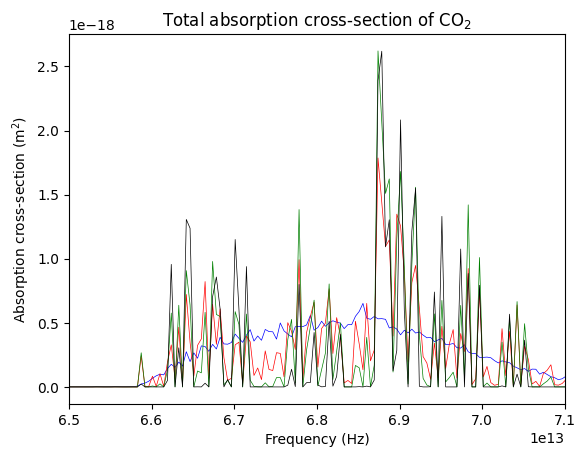

In [6]:
plt.figure()
plt.plot(freq_array, absorption_sigma_z[0, :],'b',linewidth=0.5)
plt.plot(freq_array, absorption_sigma_z[10, :],'r',linewidth=0.5)
plt.plot(freq_array, absorption_sigma_z[20, :],'g',linewidth=0.5)
plt.plot(freq_array, absorption_sigma_z[49, :],'k',linewidth=0.5)
plt.xlabel(r'Frequency (Hz)')
plt.ylabel(r'Absorption cross-section (m$^2$)')
plt.title(r'Total absorption cross-section of CO$_2$')
plt.xlim(0.65*1e14, 0.71*1e14)
plt.show()

In [7]:
def partition_function_linearT(energy_levels, degeneracies, T_atm_0, constant, z_array):
    M=len(energy_levels)
    Z_array = np.zeros_like(z_array)

    for j, z in enumerate(z_array):
        T_z = temperature(z, T_atm_0, constant)
        
        Z=0
        
        for i in range(M):
            Z += np.sum(degeneracies * np.exp(-energy_levels / (const.k_B.value * T_z)))
        
        Z_array[j] = Z

    return Z_array

#The output is an array with the partition functions for the different heights

def energy_level_density_linearT(energy_level, degeneracy, T_atm_0, constant, z_array, Z_array, n_tot_array):

    n_level_array = np.zeros_like(z_array)

    for j, z in enumerate(z_array):
        T_z = temperature(z, T_atm_0, constant)
        Numerator = degeneracy * np.exp(-energy_level / (const.k_B.value * T_z))
        P_z = Numerator / Z_array[j]
        n_level_array[j] = n_tot_array[j] * P_z

    return n_level_array

#The output is an array with the the density of a certain energy level for the different heights
#Be careful with the input parameters, many are arrays

In [8]:
# Extract both lower and upper levels
levels_lower = pd.DataFrame({
    'E': df['elower'],
    'g': df['gpp'],
    'label': 'lower'
})
levels_upper = pd.DataFrame({
    'E': df['elower'] + df['nu'],
    'g': df['gp'],
    'label': 'upper'
})

# Combine and remove duplicates
levels_all = pd.concat([levels_lower, levels_upper], ignore_index=True)
levels_unique = levels_all.drop_duplicates(subset=['E', 'g']).sort_values(by='E').reset_index(drop=True)

E_cm = levels_unique['E'].values*(1/u.cm) 
E_J = E_cm.to(u.J, equivalencies=u.spectral()) 

energy_levels = E_J.value
degeneracies = levels_unique['g'].values


In [9]:
## Some vectorized functions to optimize the next block of code 

def vec_partition_function_linearT(energy_levels, degeneracies, T_atm_0, constant, z_array):
    """
    Vectorized partition function at each altitude for linear temperature profile.
    """
    T_z = temperature(z_array, T_atm_0, constant)
    # Vectorized Boltzmann sum
    Z_array = np.sum(
        degeneracies[:, None] * np.exp(-energy_levels[:, None] / (const.k_B.value * T_z)),
        axis=0,
    )
    return Z_array


def vec_density_profile_atm_linearT(z, T_atm_0, Mm, M_p, R_p, P0, constant):
    """
    Vectorized density profile assuming hydrostatic equilibrium + ideal gas.
    """
    T_z = temperature(z, T_atm_0, constant)
    g = surface_gravity(M_p, R_p)
    mol_mass = Mm / (1000 * const.N_A.value)  # convert g/mol → kg/molecule
    exponent = (g * mol_mass) / (constant * const.k_B.value)
    n = (P0 / (const.k_B.value * T_z)) * (1 - constant * z / T_atm_0) ** exponent
    return n


def vec_energy_level_density_linearT(energy_levels, degeneracies, T_atm_0, constant, z_array, Z_array, n_tot_array):
    """
    Vectorized total density of all energy levels across altitude.
    """
    T_z = temperature(z_array, T_atm_0, constant)
    Boltzmann_factor = np.exp(-energy_levels[:, None] / (const.k_B.value * T_z))
    P_z = (degeneracies[:, None] * Boltzmann_factor) / Z_array
    n_level_array = np.sum(n_tot_array * P_z, axis=0)
    return n_level_array

def effective_scale_height(T_atm_0, constant, z_array, M_p, R_p, Mm):
    """
    Vectorized effective height
    """
    g = surface_gravity(M_p, R_p)
    T_z = temperature(z_array, T_atm_0, constant)
    H_eff = T_z / ((((Mm/(1000 * const.N_A.value)) * g)/ const.k_B.value) - constant)
    return H_eff


In [10]:
##Computing tau 
zmax = 1000000  # 1000 km
z_array = np.linspace(0, zmax, num=50)
H_eff = effective_scale_height(T_atm_0, constant, z_array, M_p, R_p, Mm_CO2)
R_star = 0.895*const.R_sun.value

# --- Step 1: Partition function at each height ---
Z_array = vec_partition_function_linearT(energy_levels, degeneracies, T_atm_0, constant, z_array)

# --- Step 2: Atmospheric density profile ---
n_tot_array = vec_density_profile_atm_linearT(z_array, T_atm_0, Mm_CO2, M_p, R_p, P0, constant)

# --- Step 3: CO2 density from Boltzmann distribution ---
n_CO2 = vec_energy_level_density_linearT(energy_levels, degeneracies, T_atm_0, constant, z_array, Z_array, n_tot_array)

# --- Step 4: Optical depth and transmission (vectorized) ---
tau_nu = absorption_sigma_z * n_CO2[:, None] * np.sqrt(2 * np.pi * (z_array[:, None] + R_p) * H_eff[:, None])
T_nu = np.exp(-tau_nu)

# --- Step 5: Effective radius and transit depth ---
R_eff2 = R_p**2 + 2 * np.trapezoid((1 - T_nu) * (z_array[:, None] + R_p), z_array + R_p, axis=0)
delta_nu = R_eff2 / R_star**2



In [11]:
def fast_binning(x, y, bins, error=None, std=False):
    bins = np.arange(np.min(x), np.max(x), bins)
    d = np.digitize(x, bins)

    n = np.max(d) + 2

    binned_x = np.empty(n)
    binned_y = np.empty(n)
    binned_error = np.empty(n)

    binned_x[:] = -np.pi
    binned_y[:] = -np.pi
    binned_error[:] = -np.pi

    for i in range(0, n):
        s = np.where(d == i)
        if len(s[0]) > 0:
            s = s[0]
            binned_y[i] = np.mean(y[s])
            binned_x[i] = np.mean(x[s])
            binned_error[i] = np.std(y[s]) / np.sqrt(len(s))

            if error is not None:
                err = error[s]
                binned_error[i] = np.sqrt(np.sum(np.power(err, 2))) / len(err)
            else:
                binned_error[i] = np.std(y[s]) / np.sqrt(len(s))

    nans = binned_x == -np.pi
    
    return binned_x[~nans], binned_y[~nans], binned_error[~nans]

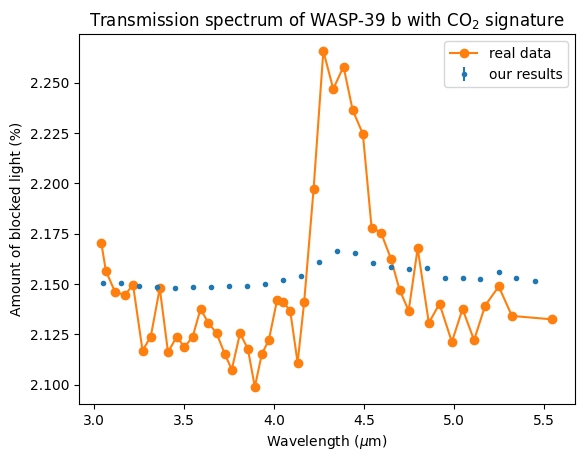

In [12]:
lambda_array = (const.c.value/freq_array)*1e6
y = np.array(delta_nu)*100
binned_data = fast_binning(lambda_array, y, 0.1)
observed_data = pd.read_csv('WASP39b_data.csv')
observed_x = observed_data.iloc[:,0]
observed_y = observed_data.iloc[:,1]

plt.figure()
plt.errorbar(binned_data[0], binned_data[1], binned_data[2], fmt='.', label='our results')
plt.plot(observed_x, observed_y, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')
plt.legend()
plt.show()

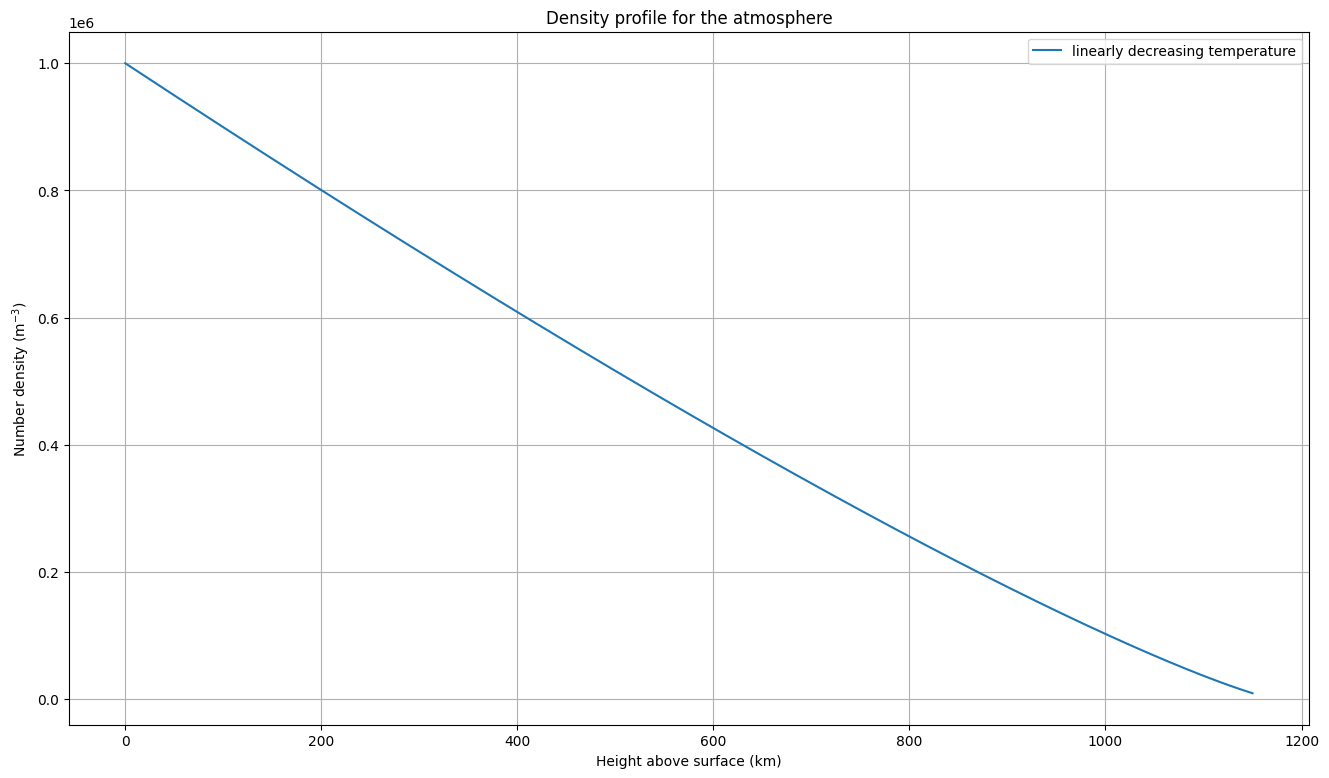

In [13]:
#I did this to ensure a reasonable choice of zmax 
#Test of the density profiles (using data for the WASP-39 b) 
z = np.linspace(0, 1150000, num=1000)
T_atm = 900 + 273
Mm = 2.3 
P0 = 1e6  
M_p = 0.28 * const.M_jup.value 
R_p = 1.27 * const.R_jup.value 
constant = 1e-3 
g = surface_gravity(M_p, R_p)

plt.figure(figsize=(16,9))
plt.plot(z/1000,  P0 * (1 - constant * z / T_atm_0) ** ((g * (Mm/(1000 * const.N_A.value))) / (constant * const.k_B.value)), label='linearly decreasing temperature')
plt.xlabel("Height above surface (km)")
plt.ylabel("Number density " + r'(m$^{-3}$)')
plt.title("Density profile for the atmosphere")
plt.legend()
plt.grid()
plt.show()